In [78]:
import pandas as pd

decisao = pd.read_csv("../data/eventos_com_decisao.csv")
playbooks = pd.read_csv("../data/playbooks.csv")

spy = pd.read_csv("../data/spy_precos.csv")
ewz = pd.read_csv("../data/ewz_precos.csv")
usdbrl = pd.read_csv("../data/usdbrl_precos.csv")
ibov = pd.read_csv("../data/ibov_precos.csv")

spy["ativo"] = "SPY"
ewz["ativo"] = "EWZ"
usdbrl["ativo"] = "BRL=X"

precos_todos = pd.concat([spy, ewz, usdbrl], ignore_index=True)

decisao["data"] = pd.to_datetime(decisao["data"], format="mixed").dt.strftime("%Y-%m-%d")
precos_todos["data"] = pd.to_datetime(precos_todos["data"], format="mixed").dt.strftime("%Y-%m-%d")
ibov["data"] = pd.to_datetime(ibov["data"], format="mixed").dt.strftime("%Y-%m-%d")

print(decisao["indicador"].value_counts())

indicador
Payroll_EUA    43
CPI_EUA        39
IPCA_BR        34
Selic_BR       18
Name: count, dtype: int64


In [79]:
def calcular_retorno_operacao(row):
    if pd.isna(row["retorno_pct"]):
        return None
    if row["direcao"] == "comprar":
        return row["retorno_pct"] * row["tamanho_posicao"]
    elif row["direcao"] == "vender":
        return -row["retorno_pct"] * row["tamanho_posicao"]
    return 0

operacoes["retorno_operacao"] = operacoes.apply(calcular_retorno_operacao, axis=1)
operacoes = operacoes.dropna(subset=["retorno_operacao"])
operacoes["data"] = pd.to_datetime(operacoes["data"])
print(f"Total de operações válidas: {len(operacoes)}")
print(operacoes["indicador"].value_counts())

Total de operações válidas: 12
indicador
CPI_EUA        5
IPCA_BR        3
Selic_BR       2
Payroll_EUA    2
Name: count, dtype: int64


In [80]:
def calcular_retorno_operacao(row):
    if pd.isna(row["retorno_pct"]):
        return None
    if row["direcao"] == "comprar":
        return row["retorno_pct"] * row["tamanho_posicao"]
    elif row["direcao"] == "vender":
        return -row["retorno_pct"] * row["tamanho_posicao"]
    return 0

operacoes["retorno_operacao"] = operacoes.apply(calcular_retorno_operacao, axis=1)
operacoes = operacoes.dropna(subset=["retorno_operacao"])
operacoes["data"] = pd.to_datetime(operacoes["data"])
print(f"Total de operações válidas: {len(operacoes)}")
print(operacoes["indicador"].value_counts())

Total de operações válidas: 12
indicador
CPI_EUA        5
IPCA_BR        3
Selic_BR       2
Payroll_EUA    2
Name: count, dtype: int64


In [81]:
capital_inicial = 100
operacoes = operacoes.sort_values("data")
operacoes["capital"] = capital_inicial * (1 + operacoes["retorno_operacao"] / 100).cumprod()
print(operacoes[["data", "indicador", "retorno_operacao", "capital"]])

          data    indicador  retorno_operacao     capital
1   2023-04-12      CPI_EUA         -0.195852   99.804148
73  2023-08-03     Selic_BR          0.357452  100.160901
13  2024-04-10      CPI_EUA          0.214111  100.375356
82  2024-12-12     Selic_BR          0.589522  100.967091
63  2025-02-11      IPCA_BR          0.756970  101.731382
64  2025-03-12      IPCA_BR         -0.214771  101.512892
65  2025-04-11      IPCA_BR         -0.215177  101.294460
33  2026-02-13      CPI_EUA          0.028703  101.323534
128 2026-03-06  Payroll_EUA         -0.887500  100.424288
35  2026-04-10      CPI_EUA         -0.019876  100.404327
131 2026-06-05  Payroll_EUA          2.337647  102.751426
38  2026-07-14      CPI_EUA          0.113640  102.868193


In [82]:
retorno_total = (operacoes["capital"].iloc[-1] / capital_inicial - 1) * 100
volatilidade = operacoes["retorno_operacao"].std()
sharpe = operacoes["retorno_operacao"].mean() / operacoes["retorno_operacao"].std()
win_rate = (operacoes["retorno_operacao"] > 0).mean() * 100
pico = operacoes["capital"].cummax()
max_drawdown = ((operacoes["capital"] - pico) / pico).min() * 100

print(f"Retorno total: {retorno_total:.2f}%")
print(f"Volatilidade: {volatilidade:.2f}%")
print(f"Sharpe: {sharpe:.2f}")
print(f"Máx. drawdown: {max_drawdown:.2f}%")
print(f"Win rate: {win_rate:.2f}%")

Retorno total: 2.87%
Volatilidade: 0.79%
Sharpe: 0.30
Máx. drawdown: -1.30%
Win rate: 58.33%


In [83]:
metricas_por_indicador = operacoes.groupby("indicador").agg(
    total_operacoes=("retorno_operacao", "count"),
    retorno_medio=("retorno_operacao", "mean"),
    win_rate=("retorno_operacao", lambda x: (x > 0).mean() * 100)
).round(2)
print(metricas_por_indicador)

             total_operacoes  retorno_medio  win_rate
indicador                                            
CPI_EUA                    5           0.03     60.00
IPCA_BR                    3           0.11     33.33
Payroll_EUA                2           0.73     50.00
Selic_BR                   2           0.47    100.00


In [84]:
ops_eua = operacoes[operacoes["indicador"].isin(["CPI_EUA", "Payroll_EUA"])].copy()
comparacao_eua = ops_eua[["data", "indicador", "direcao", "retorno_operacao", "retorno_pct"]].rename(
    columns={"retorno_operacao": "retorno_faro", "retorno_pct": "retorno_sp500"}
)
print(comparacao_eua.sort_values("data").to_string(index=False))

      data   indicador direcao  retorno_faro  retorno_sp500
2023-04-12     CPI_EUA comprar     -0.195852      -0.407599
2024-04-10     CPI_EUA  vender      0.214111      -1.001323
2026-02-13     CPI_EUA comprar      0.028703       0.070450
2026-03-06 Payroll_EUA comprar     -0.887500      -1.310713
2026-04-10     CPI_EUA comprar     -0.019876      -0.066178
2026-06-05 Payroll_EUA  vender      2.337647      -2.580937
2026-07-14     CPI_EUA comprar      0.113640       0.355064


In [85]:
ops_br = operacoes[operacoes["indicador"].isin(["IPCA_BR", "Selic_BR"])].copy()
ops_br["data"] = pd.to_datetime(ops_br["data"]).dt.strftime("%Y-%m-%d")
ops_br = ops_br.merge(ibov[["data", "retorno_pct"]], on="data", how="left", suffixes=("", "_ibov"))

comparacao_br = ops_br[["data", "indicador", "direcao", "retorno_operacao", "retorno_pct_ibov"]].rename(
    columns={"retorno_operacao": "retorno_faro", "retorno_pct_ibov": "retorno_ibovespa"}
)
print(comparacao_br.sort_values("data").to_string(index=False))

      data indicador direcao  retorno_faro  retorno_ibovespa
2023-08-03  Selic_BR comprar      0.357452         -0.225883
2024-12-12  Selic_BR  vender      0.589522         -2.740117
2025-02-11   IPCA_BR comprar      0.756970          0.756538
2025-03-12   IPCA_BR  vender     -0.214771          0.289052
2025-04-11   IPCA_BR  vender     -0.215177          1.050216


In [86]:
ibov_full = pd.read_csv("../data/ibov_precos.csv")
ibov_full["data"] = pd.to_datetime(ibov_full["data"], format="mixed")

spy_puro = spy_full[(spy_full["data"] >= data_inicio) & (spy_full["data"] <= data_fim)].copy()
spy_puro["capital"] = 100 * (1 + spy_puro["retorno_pct"] / 100).cumprod()

ibov_puro = ibov_full[(ibov_full["data"] >= data_inicio) & (ibov_full["data"] <= data_fim)].copy()
ibov_puro["capital"] = 100 * (1 + ibov_puro["retorno_pct"] / 100).cumprod()

spy_hibrido = spy_puro.copy()
for _, op in ops_eua.iterrows():
    mask = spy_hibrido["data"] == pd.to_datetime(op["data"])
    spy_hibrido.loc[mask, "retorno_pct"] = op["retorno_operacao"]
spy_hibrido["capital"] = 100 * (1 + spy_hibrido["retorno_pct"] / 100).cumprod()

ibov_hibrido = ibov_puro.copy()
for _, op in ops_br.iterrows():
    mask = ibov_hibrido["data"] == pd.to_datetime(op["data"])
    ibov_hibrido.loc[mask, "retorno_pct"] = op["retorno_operacao"]
ibov_hibrido["capital"] = 100 * (1 + ibov_hibrido["retorno_pct"] / 100).cumprod()

print(f"S&P 500 puro: {(spy_puro['capital'].iloc[-1]/100-1)*100:.2f}%")
print(f"Ibovespa puro: {(ibov_puro['capital'].iloc[-1]/100-1)*100:.2f}%")
print(f"S&P + FARO: {(spy_hibrido['capital'].iloc[-1]/100-1)*100:.2f}%")
print(f"Ibovespa + FARO: {(ibov_hibrido['capital'].iloc[-1]/100-1)*100:.2f}%")

S&P 500 puro: 91.18%
Ibovespa puro: 66.31%
S&P + FARO: 104.12%
Ibovespa + FARO: 69.98%


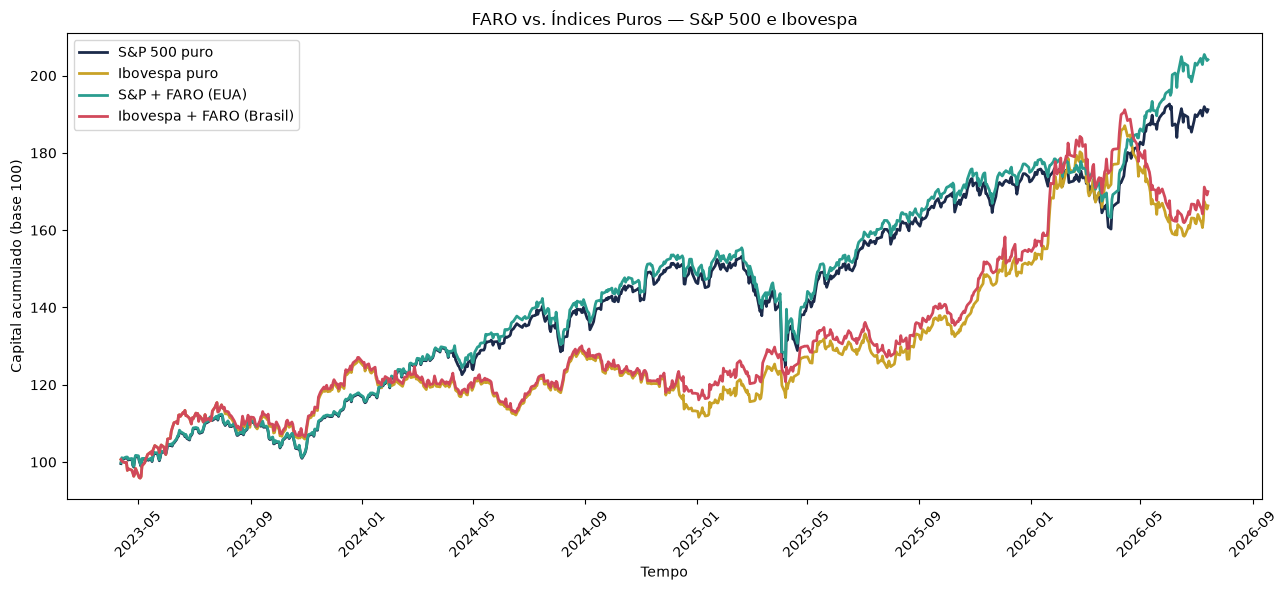

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 6))

plt.plot(spy_puro["data"], spy_puro["capital"], label="S&P 500 puro", color="#1b2a4a", linewidth=2)
plt.plot(ibov_puro["data"], ibov_puro["capital"], label="Ibovespa puro", color="#c9a227", linewidth=2)
plt.plot(spy_hibrido["data"], spy_hibrido["capital"], label="S&P + FARO (EUA)", color="#2a9d8f", linewidth=2)
plt.plot(ibov_hibrido["data"], ibov_hibrido["capital"], label="Ibovespa + FARO (Brasil)", color="#d1495b", linewidth=2)

plt.xlabel("Tempo")
plt.ylabel("Capital acumulado (base 100)")
plt.title("FARO vs. Índices Puros — S&P 500 e Ibovespa")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig("../data/comparacao_4_curvas.png", dpi=150)
plt.show()

In [90]:
def retorno_por_ano(df, nome_coluna_capital="capital"):
    df = df.copy()
    df["ano"] = pd.to_datetime(df["data"]).dt.year
    resultado = df.groupby("ano")[nome_coluna_capital].agg(["first", "last"])
    resultado["retorno_ano_pct"] = (resultado["last"] / resultado["first"] - 1) * 100
    return resultado["retorno_ano_pct"]

tabela_anual = pd.DataFrame({
    "S&P 500 puro": retorno_por_ano(spy_puro),
    "S&P + FARO (EUA)": retorno_por_ano(spy_hibrido),
    "Ibovespa puro": retorno_por_ano(ibov_puro),
    "Ibovespa + FARO (Brasil)": retorno_por_ano(ibov_hibrido),
}).round(2)

print(tabela_anual)

      S&P 500 puro  S&P + FARO (EUA)  Ibovespa puro  Ibovespa + FARO (Brasil)
ano                                                                          
2023         17.80             17.80          25.54                     26.27
2024         25.59             27.13          -9.36                     -6.25
2025         18.01             18.01          34.13                     31.79
2026         10.64             16.44          10.03                     10.03
